In this notebook we perform EDA on our dataset to get a feel for the data at hand. 

In [ ]:
import os 
from dotenv import load_dotenv
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

# Load the file path. 
load_dotenv()
path = os.getenv("TRAINING_DATA_URL")

# Load the dataset as a pandas df and check the import 
titanic_df = pd.read_csv(path)
titanic_df.head()

In [ ]:
# Discard the id, name and ticket columns. 
titanic_df_new = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
# Obtain the column types as well as some general information about the data.
print(titanic_df_new.shape)
print(titanic_df_new.dtypes)

In [ ]:
# General Information 
print(titanic_df_new.describe())
print(titanic_df_new.describe(include=np.object_))
print(titanic_df_new.info())
print(titanic_df_new["Survived"].value_counts(normalize=True))
titanic_df_new["Survived"].value_counts().plot.bar(color=['red','green'], y="Count", rot=0, alpha=0.75)

In [ ]:
# Lets compute the distribution of sex.
pd.DataFrame(data=[titanic_df_new["Sex"].value_counts(), 
                   round(titanic_df_new["Sex"].value_counts(normalize=True), 2) * 100])

In [ ]:
# Out of curiosity lets check what was the busiest maritime passenger terminal.
pd.DataFrame(data=[titanic_df_new["Embarked"].value_counts(), 
                   round(titanic_df_new["Embarked"].value_counts(normalize=True), 2) * 100])

In [ ]:
# Group the ages into bin and observe their distribution.
titanic_df_new['Age_group'] = pd.cut(titanic_df_new['Age'], bins=[0, 12, 17, 63, titanic_df_new['Age'].max()], labels=['children', 'teenager', 'adult', 'elderly'])
print(pd.DataFrame(data = [titanic_df_new['Age_group'].value_counts(),
      titanic_df_new['Age_group'].value_counts(normalize=True)]))

titanic_df_new["Age_group"].value_counts().plot.bar(color=['red','green', 'blue', 'yellow'], y="Count", rot=0, alpha=0.75, title='Distribution of Age Groups', xlabel='Age Group')

In [30]:
# Get the survival rate per age group.
pd.concat([titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(),
           round(titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(normalize=True), 2) * 100], axis=1)

count  proportion
Age_group Survived                   
children  1            40        58.0
          0            29        42.0
teenager  0            23        52.0
          1            21        48.0
adult     0           360        61.0
          1           228        39.0
elderly   0            12        92.0
          1             1         8.0

Text(0, 0.5, 'Frequency')

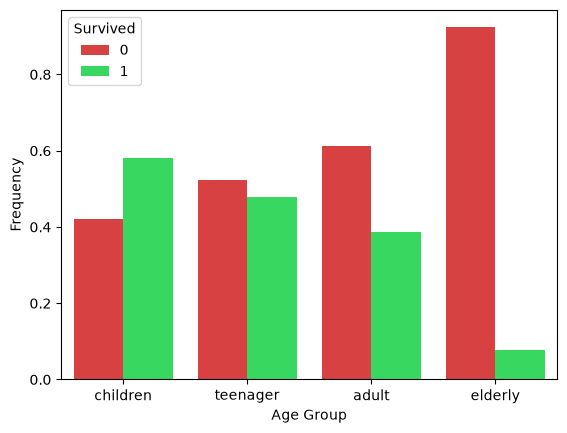

In [31]:
# Plot the distribution of survival by age.
import seaborn as sns 
ax = sns.barplot(
    x="Age_group",
    y="proportion",
    hue="Survived",
    data=titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(normalize=True).reset_index(), 
    palette={0: "#f02828", 1: "#1ef153"}
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Frequency")

In [32]:
# Get the survival rate per sex.
pd.concat([titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(),
           round(titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(normalize=True), 2) * 100], axis=1)


count  proportion
Sex    Survived                   
female 1           233        74.0
       0            81        26.0
male   0           468        81.0
       1           109        19.0

In [ ]:
# Plot the distribution of survival by sex.
ax = sns.barplot(
    x="Sex",
    y="proportion",
    hue="Survived",
    data=titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(normalize=True).reset_index(), 
    palette={0: "#f02828", 1: "#1ef153"}
)

ax.set_xlabel("Sex")
ax.set_ylabel("Frequency")

In [ ]:
# Lets compute the correlation matrix.